In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Necessary Dependencies
import numpy as np
import pandas as pd
!pip install utils
from utils import *
from glob import glob
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from itertools import chain
from datetime import datetime
import statistics
from tqdm import tqdm
import tensorflow as tf
# DenseNet Dependencies
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.activations import sigmoid
from tensorflow.keras.layers import Dense,Conv2D, Flatten, Dropout, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.metrics import Accuracy, Precision, Recall, AUC, BinaryAccuracy, FalsePositives, FalseNegatives, TruePositives, TrueNegatives
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications import DenseNet121, DenseNet169, DenseNet201, VGG16, ResNet50
from keras import backend as K
from tensorflow.keras import Sequential
import keras
import matplotlib
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from sklearn.metrics import roc_curve, auc


  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=86bdbf8512cb3ae08312025017fbb6ac744e5d8176ff60e11362972bb6d4aee2
  Stored in directory: /root/.cache/pip/wheels/b6/a1/81/1036477786ae0e17b522f6f5a838f9bc4288d1016fc5d0e1ec
Successfully built utils


In [ ]:
cd /content/drive/MyDrive/Digilians/Term_2/Deeplearning/Lab_4/6.Bone fracture using CNN


/content/drive/MyDrive/Digilians/Term_2/Deeplearning/Lab_4/6.Bone fracture using CNN


In [ ]:
path, dirs, files = next(os.walk("/content/drive/MyDrive/Digilians/Term_2/Deeplearning/Lab_4/6.Bone fracture using CNN/dataset/train/fractured"))
file_count = len(files)
print('fractured:',file_count)
path, dirs, files = next(os.walk("/content/drive/MyDrive/Digilians/Term_2/Deeplearning/Lab_4/6.Bone fracture using CNN/dataset/train/not fractured"))
file_count = len(files)
print('not fractured:',file_count)

fractured: 2078
not fractured: 2019


In [ ]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32

train_df = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Digilians/Term_2/Deeplearning/Lab_4/6.Bone fracture using CNN/dataset/test",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True
)

val_df = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Digilians/Term_2/Deeplearning/Lab_4/6.Bone fracture using CNN/dataset/val",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_df = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Digilians/Term_2/Deeplearning/Lab_4/6.Bone fracture using CNN/dataset/test",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 399 files belonging to 2 classes.
Found 404 files belonging to 2 classes.
Found 399 files belonging to 2 classes.


In [ ]:
y_true = np.concatenate([y for x, y in test_df], axis=0)

In [ ]:
train_df = train_df.prefetch(buffer_size=32)
val_df = val_df.prefetch(buffer_size=32)

In [ ]:
# Hyperparameters
IMG_IND=224
IMG_SHAPE = (IMG_IND,IMG_IND,3)
LOSS = BinaryCrossentropy() # Not un-weighted
SEED = 2
BATCH_SIZE = 16

In [ ]:
def get_callbacks(model_name):
    callbacks =[]

    checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=f'model.{model_name}.h5', verbose=1, monitor='val_loss',mode='min',save_best_only=True)
    callbacks.append(checkpoint)
    anne = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=2, min_lr=0.0000001,min_delta=0.00001,mode='auto')
    callbacks.append(anne)
    earlystop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
    callbacks.append(earlystop)

    return callbacks

## Dense Net Model

In [ ]:
OPTIMIZER =Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

base_model = tf.keras.applications.DenseNet121(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable = True

x = base_model.output     # last layer

x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid',name='Final')(x)
model = Model(inputs=base_model.input, outputs=predictions)
#model.load_weights(dire)
model.compile(loss ='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy'])

In [ ]:
# Need to know the number of layers

print(len(model.layers))


429


In [ ]:
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 6,954,881 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

None


In [ ]:
callbacks = get_callbacks('dense121')
history = model.fit( train_df,epochs=50,
                    validation_data= val_df,
                    callbacks=[callbacks])

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6542 - loss: 0.7292  
Epoch 1: val_loss improved from None to 12.72665, saving model to model.dense121.h5



Epoch 1: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 408s 18s/step - accuracy: 0.7218 - loss: 0.5931 - val_accuracy: 0.4158 - val_loss: 12.7267 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8947 - loss: 0.2257
Epoch 2: val_loss improved from 12.72665 to 5.65407, saving model to model.dense121.h5



Epoch 2: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 594ms/step - accuracy: 0.8922 - loss: 0.2281 - val_accuracy: 0.4158 - val_loss: 5.6541 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9020 - loss: 0.2266
Epoch 3: val_loss did not improve from 5.65407
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 425ms/step - accuracy: 0.8872 - loss: 0.2830 - val_accuracy: 0.4579 - val_loss: 11.6708 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9526 - loss: 0.1335
Epoch 4: val_loss did not improve from 5.65407
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 384ms/step - accuracy: 0.9624 - loss: 0.1152 - val_accuracy: 0.4158 - val_loss: 17.6190 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9801 - loss: 0.0480
Epoch 5: val_loss did not improve from 5.65407
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 420ms/step - accuracy: 0.9749 - loss: 0.0545 - val_accuracy: 0.4208 - val_loss: 15.1528 - le


Epoch 8: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 803ms/step - accuracy: 0.9875 - loss: 0.0411 - val_accuracy: 0.6782 - val_loss: 3.8379 - learning_rate: 5.0000e-04
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9810 - loss: 0.0553
Epoch 9: val_loss did not improve from 3.83790
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.9825 - loss: 0.0528 - val_accuracy: 0.6485 - val_loss: 6.4576 - learning_rate: 5.0000e-04
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9912 - loss: 0.0189
Epoch 10: val_loss improved from 3.83790 to 1.04456, saving model to model.dense121.h5



Epoch 10: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 761ms/step - accuracy: 0.9900 - loss: 0.0206 - val_accuracy: 0.8564 - val_loss: 1.0446 - learning_rate: 5.0000e-04
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9968 - loss: 0.0335
Epoch 11: val_loss did not improve from 1.04456
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.9975 - loss: 0.0199 - val_accuracy: 0.8020 - val_loss: 1.3212 - learning_rate: 5.0000e-04
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 1.0000 - loss: 0.0049
Epoch 12: val_loss did not improve from 1.04456
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 601ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.7946 - val_loss: 1.2753 - learning_rate: 5.0000e-04
Epoch 13/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 1.0000 - loss: 0.0037
Epoch 13: val_loss improved from 1.04456 to 0.81987, saving model to model.dense121.h5


...


Epoch 29: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 560ms/step - accuracy: 1.0000 - loss: 1.7462e-04 - val_accuracy: 0.9703 - val_loss: 0.1859 - learning_rate: 5.0000e-04
Epoch 30/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 1.0000 - loss: 3.4783e-04
Epoch 30: val_loss improved from 0.18593 to 0.17731, saving model to model.dense121.h5



Epoch 30: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 558ms/step - accuracy: 1.0000 - loss: 4.6883e-04 - val_accuracy: 0.9728 - val_loss: 0.1773 - learning_rate: 5.0000e-04
Epoch 31/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 1.0000 - loss: 1.1778e-04
Epoch 31: val_loss improved from 0.17731 to 0.16512, saving model to model.dense121.h5



Epoch 31: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 544ms/step - accuracy: 1.0000 - loss: 1.4217e-04 - val_accuracy: 0.9728 - val_loss: 0.1651 - learning_rate: 5.0000e-04
Epoch 32/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 1.0000 - loss: 2.6887e-04
Epoch 32: val_loss improved from 0.16512 to 0.16272, saving model to model.dense121.h5



Epoch 32: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 582ms/step - accuracy: 1.0000 - loss: 3.6584e-04 - val_accuracy: 0.9728 - val_loss: 0.1627 - learning_rate: 5.0000e-04
Epoch 33/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 1.0000 - loss: 1.2753e-04
Epoch 33: val_loss improved from 0.16272 to 0.14873, saving model to model.dense121.h5



Epoch 33: finished saving model to model.dense121.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 562ms/step - accuracy: 1.0000 - loss: 1.3219e-04 - val_accuracy: 0.9728 - val_loss: 0.1487 - learning_rate: 5.0000e-04
Epoch 34/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 1.0000 - loss: 2.9694e-04
Epoch 34: val_loss did not improve from 0.14873
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 412ms/step - accuracy: 1.0000 - loss: 3.7569e-04 - val_accuracy: 0.9728 - val_loss: 0.1504 - learning_rate: 5.0000e-04
Epoch 35/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 1.0000 - loss: 1.3659e-04
Epoch 35: val_loss did not improve from 0.14873
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 420ms/step - accuracy: 1.0000 - loss: 1.2596e-04 - val_accuracy: 0.9728 - val_loss: 0.1536 - learning_rate: 5.0000e-04
Epoch 36/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 1.0000 - loss: 1.1107e-04
Epoch 36: val_loss did not improve from 0.14873
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 1.0000 - loss: 1.3328e-04 - v

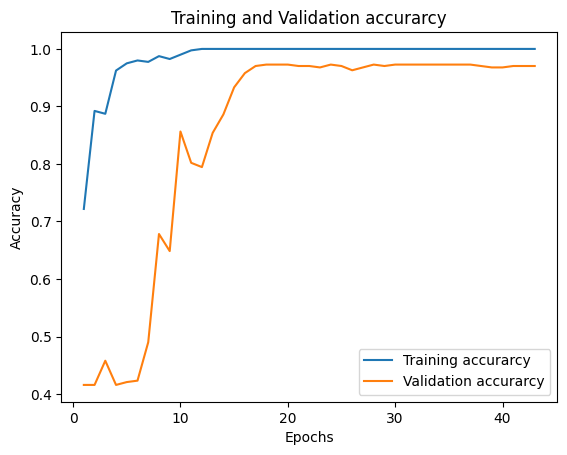

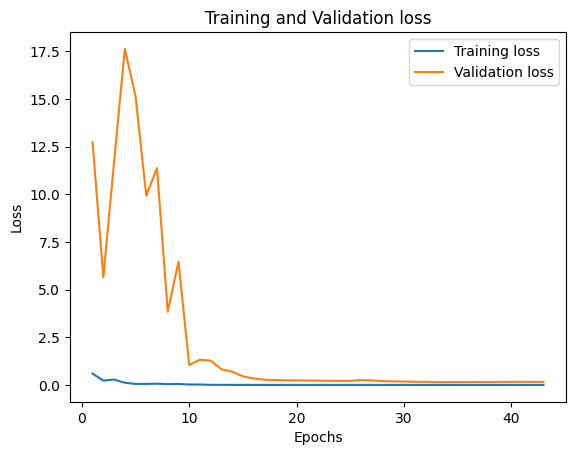

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model = keras.models.load_model('model.dense121.h5')

In [ ]:
results = model.evaluate(test_df, verbose=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 753ms/step - accuracy: 1.0000 - loss: 3.8313e-05


In [ ]:
y_pred = model.predict(test_df, verbose=1).round()   #  for sigmoid  >= 0.5 --> 1 , 0
y_pred = y_pred.flatten()

13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step


               precision    recall  f1-score   support

not fractured     1.0000    1.0000    1.0000       199
    fractured     1.0000    1.0000    1.0000       200

     accuracy                         1.0000       399
    macro avg     1.0000    1.0000    1.0000       399
 weighted avg     1.0000    1.0000    1.0000       399



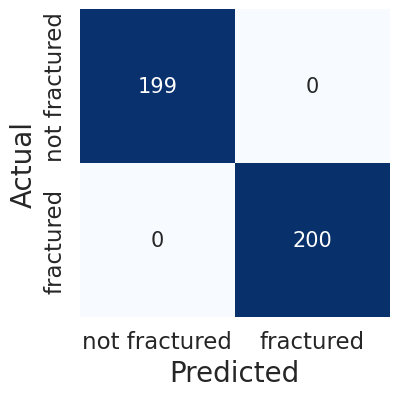

In [ ]:
from sklearn.metrics import confusion_matrix
from imblearn.metrics import sensitivity_specificity_support
from sklearn.metrics import classification_report
import seaborn as sn
import pandas as pd

target_names= ['not fractured', 'fractured']

report=classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)


disp = confusion_matrix(y_true, y_pred)
disp.astype('int')
pd.options.display.float_format = '{:.5f}'.format
df_cm = pd.DataFrame(disp, target_names, target_names)
# plt.figure(figsize=(10,7))
fig, ax = plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5) # for label size
sn.heatmap(df_cm, annot=True, annot_kws={"size": 15},ax=ax, cmap="Blues" , fmt='g',cbar=False) # font size
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat", bbox_inches='tight')
plt.show()


## RESNet 50

In [ ]:
OPTIMIZER =Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
base_model = tf.keras.applications.ResNet50(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')

base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid',name='Final')(x)
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(loss ='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy'])

In [ ]:
callbacks = get_callbacks('resnet50')
history = model.fit( train_df,epochs=20,
                    validation_data= val_df,
                    callbacks=[callbacks])

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6153 - loss: 0.9160   
Epoch 1: val_loss improved from None to 542.51483, saving model to model.resnet50.h5



Epoch 1: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step - accuracy: 0.6466 - loss: 0.9520 - val_accuracy: 0.4158 - val_loss: 542.5148 - learning_rate: 0.0010
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.7939 - loss: 0.4865
Epoch 2: val_loss did not improve from 542.51483
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - accuracy: 0.7694 - loss: 0.5017 - val_accuracy: 0.4158 - val_loss: 18450.4785 - learning_rate: 0.0010
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8040 - loss: 0.5859
Epoch 3: val_loss did not improve from 542.51483
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 896ms/step - accuracy: 0.8170 - loss: 0.4900 - val_accuracy: 0.4158 - val_loss: 67879.7812 - learning_rate: 0.0010
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8807 - loss: 0.2906
Epoch 4: val_loss did not improve from 542.51483
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 487ms/step - accuracy: 0.9023 - loss: 0.2588 - val_accuracy: 0.4158 - val_loss:


Epoch 5: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9474 - loss: 0.1446 - val_accuracy: 0.4158 - val_loss: 159.8453 - learning_rate: 0.0010
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9715 - loss: 0.1115
Epoch 6: val_loss did not improve from 159.84532
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 405ms/step - accuracy: 0.9674 - loss: 0.1080 - val_accuracy: 0.4158 - val_loss: 244.3664 - learning_rate: 0.0010
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9190 - loss: 0.1897
Epoch 7: val_loss improved from 159.84532 to 31.51560, saving model to model.resnet50.h5



Epoch 7: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 585ms/step - accuracy: 0.9398 - loss: 0.1672 - val_accuracy: 0.4208 - val_loss: 31.5156 - learning_rate: 0.0010
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9567 - loss: 0.0970
Epoch 8: val_loss did not improve from 31.51560
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - accuracy: 0.9524 - loss: 0.1041 - val_accuracy: 0.4158 - val_loss: 159.4254 - learning_rate: 0.0010
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9889 - loss: 0.0461
Epoch 9: val_loss improved from 31.51560 to 20.55270, saving model to model.resnet50.h5



Epoch 9: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9850 - loss: 0.0626 - val_accuracy: 0.4282 - val_loss: 20.5527 - learning_rate: 0.0010
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9526 - loss: 0.1195
Epoch 10: val_loss improved from 20.55270 to 3.92323, saving model to model.resnet50.h5


...


Epoch 13: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 917ms/step - accuracy: 0.9724 - loss: 0.1149 - val_accuracy: 0.8837 - val_loss: 0.4708 - learning_rate: 0.0010
Epoch 14/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9796 - loss: 0.0565
Epoch 14: val_loss improved from 0.47077 to 0.44250, saving model to model.resnet50.h5



Epoch 14: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 835ms/step - accuracy: 0.9799 - loss: 0.0585 - val_accuracy: 0.8812 - val_loss: 0.4425 - learning_rate: 0.0010
Epoch 15/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9926 - loss: 0.0243
Epoch 15: val_loss improved from 0.44250 to 0.32067, saving model to model.resnet50.h5



Epoch 15: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 824ms/step - accuracy: 0.9875 - loss: 0.0284 - val_accuracy: 0.9010 - val_loss: 0.3207 - learning_rate: 0.0010
Epoch 16/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9957 - loss: 0.0144
Epoch 16: val_loss did not improve from 0.32067
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 417ms/step - accuracy: 0.9950 - loss: 0.0163 - val_accuracy: 0.9084 - val_loss: 0.3508 - learning_rate: 0.0010
Epoch 17/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9968 - loss: 0.0130
Epoch 17: val_loss did not improve from 0.32067
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9975 - loss: 0.0116 - val_accuracy: 0.8292 - val_loss: 0.7627 - learning_rate: 0.0010
Epoch 18/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 18: val_loss improved from 0.32067 to 0.27685, saving model to model.resnet50.h5



Epoch 18: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 873ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9381 - val_loss: 0.2768 - learning_rate: 0.0010
Epoch 19/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 19: val_loss improved from 0.27685 to 0.23465, saving model to model.resnet50.h5



Epoch 19: finished saving model to model.resnet50.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 976ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.9455 - val_loss: 0.2346 - learning_rate: 0.0010
Epoch 20/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 1.0000 - loss: 9.4316e-04
Epoch 20: val_loss did not improve from 0.23465
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9356 - val_loss: 0.2889 - learning_rate: 0.0010


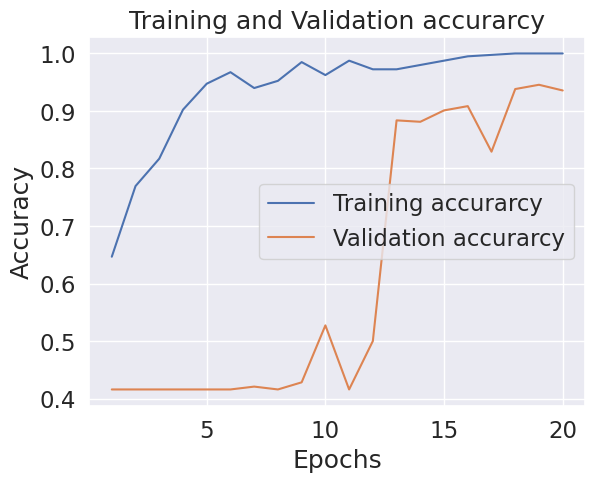

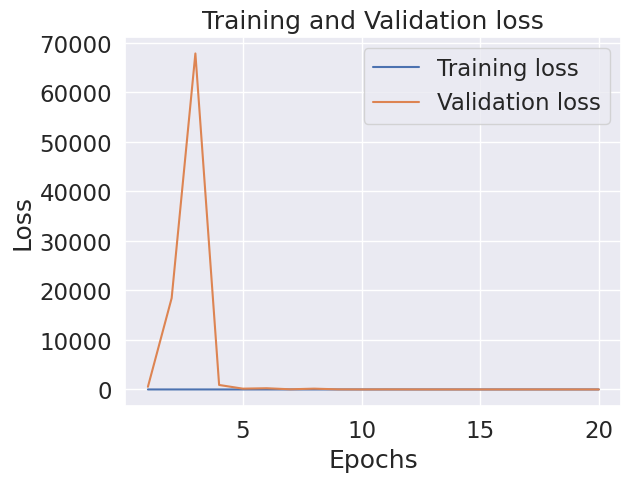

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model = keras.models.load_model('model.resnet50.h5')

In [ ]:
results = model.evaluate(test_df, steps=len(test_df), verbose=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 577ms/step - accuracy: 0.9850 - loss: 0.0512


In [ ]:
y_pred = model.predict(test_df, verbose=1).round()
y_pred = y_pred.flatten()
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 387ms/step
               precision    recall  f1-score   support

not fractured     1.0000    0.9698    0.9847       199
    fractured     0.9709    1.0000    0.9852       200

     accuracy                         0.9850       399
    macro avg     0.9854    0.9849    0.9850       399
 weighted avg     0.9854    0.9850    0.9850       399



               precision    recall  f1-score   support

not fractured     1.0000    0.9698    0.9847       199
    fractured     0.9709    1.0000    0.9852       200

     accuracy                         0.9850       399
    macro avg     0.9854    0.9849    0.9850       399
 weighted avg     0.9854    0.9850    0.9850       399



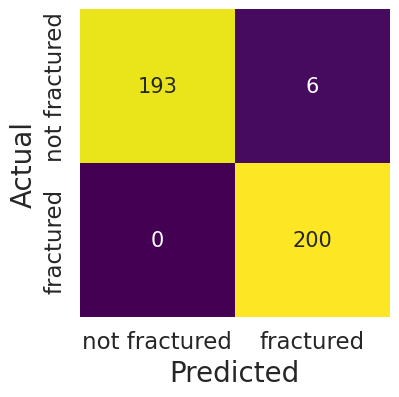

In [ ]:
from sklearn.metrics import confusion_matrix
from imblearn.metrics import sensitivity_specificity_support
from sklearn.metrics import classification_report
import seaborn as sn
import pandas as pd

report=classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)


disp = confusion_matrix(y_true, y_pred)
disp.astype('int')
pd.options.display.float_format = '{:.5f}'.format
df_cm = pd.DataFrame(disp, target_names, target_names)
# plt.figure(figsize=(10,7))
fig, ax = plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5) # for label size
sn.heatmap(df_cm, annot=True, annot_kws={"size": 15},ax=ax, cmap="viridis" , fmt='g',cbar=False) # font size
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat", bbox_inches='tight')
plt.show()


## MobileNet model

In [ ]:
OPTIMIZER =Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
base_model=tf.keras.applications.mobilenet.MobileNet(include_top=False, weights="imagenet",input_shape=IMG_SHAPE)

base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid',name='Final')(x)
model = Model(inputs=base_model.input, outputs=predictions)
#model.load_weights(dire)
model.compile(loss ='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy'])
#model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
callbacks = get_callbacks('MobileNet')
history = model.fit( train_df,epochs=20,
                    validation_data= val_df,
                    callbacks=[callbacks])

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6400 - loss: 0.8559  
Epoch 1: val_loss improved from None to 4.44406, saving model to model.MobileNet.h5



Epoch 1: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7544 - loss: 0.6482 - val_accuracy: 0.4158 - val_loss: 4.4441 - learning_rate: 0.0010
Epoch 2/20
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9436 - loss: 0.1544
Epoch 2: val_loss improved from 4.44406 to 2.50349, saving model to model.MobileNet.h5



Epoch 2: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.9499 - loss: 0.1260 - val_accuracy: 0.4257 - val_loss: 2.5035 - learning_rate: 0.0010
Epoch 3/20
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9933 - loss: 0.0271
Epoch 3: val_loss did not improve from 2.50349
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.9875 - loss: 0.0341 - val_accuracy: 0.4332 - val_loss: 2.7145 - learning_rate: 0.0010
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9903 - loss: 0.0214
Epoch 4: val_loss did not improve from 2.50349
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accuracy: 0.9875 - loss: 0.0372 - val_accuracy: 0.4158 - val_loss: 6.0684 - learning_rate: 0.0010
Epoch 5/20
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9868 - loss: 0.0516
Epoch 5: val_loss improved from 2.50349 to 2.35881, saving model to model.MobileNet.h5



Epoch 5: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step - accuracy: 0.9749 - loss: 0.0998 - val_accuracy: 0.5619 - val_loss: 2.3588 - learning_rate: 0.0010
Epoch 6/20
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9898 - loss: 0.0306
Epoch 6: val_loss improved from 2.35881 to 1.10036, saving model to model.MobileNet.h5



Epoch 6: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 535ms/step - accuracy: 0.9850 - loss: 0.0411 - val_accuracy: 0.6980 - val_loss: 1.1004 - learning_rate: 0.0010
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9633 - loss: 0.1057
Epoch 7: val_loss improved from 1.10036 to 0.67968, saving model to model.MobileNet.h5


...


Epoch 16: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - accuracy: 1.0000 - loss: 5.7187e-04 - val_accuracy: 0.9530 - val_loss: 0.4418 - learning_rate: 5.0000e-04
Epoch 17/20
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 1.0000 - loss: 4.1356e-04
Epoch 17: val_loss improved from 0.44183 to 0.39534, saving model to model.MobileNet.h5



Epoch 17: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 1.0000 - loss: 4.3956e-04 - val_accuracy: 0.9530 - val_loss: 0.3953 - learning_rate: 5.0000e-04
Epoch 18/20
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 1.0000 - loss: 4.3131e-04
Epoch 18: val_loss improved from 0.39534 to 0.36187, saving model to model.MobileNet.h5



Epoch 18: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 1.0000 - loss: 3.7903e-04 - val_accuracy: 0.9530 - val_loss: 0.3619 - learning_rate: 5.0000e-04
Epoch 19/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 3.2458e-04
Epoch 19: val_loss improved from 0.36187 to 0.33477, saving model to model.MobileNet.h5



Epoch 19: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step - accuracy: 1.0000 - loss: 3.1849e-04 - val_accuracy: 0.9554 - val_loss: 0.3348 - learning_rate: 5.0000e-04
Epoch 20/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 1.0000 - loss: 3.5811e-04
Epoch 20: val_loss improved from 0.33477 to 0.31634, saving model to model.MobileNet.h5



Epoch 20: finished saving model to model.MobileNet.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 275ms/step - accuracy: 1.0000 - loss: 3.4489e-04 - val_accuracy: 0.9579 - val_loss: 0.3163 - learning_rate: 5.0000e-04


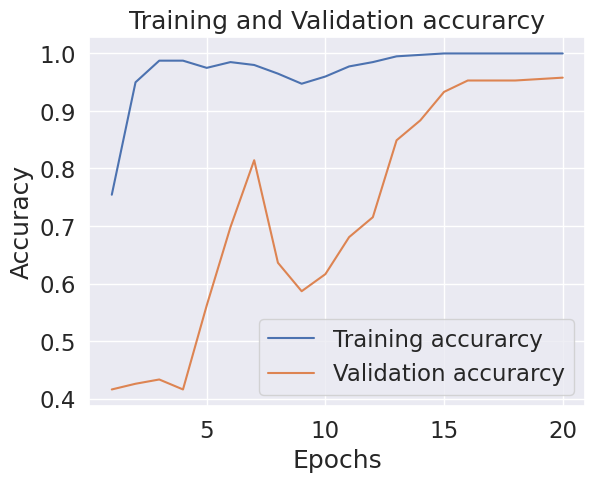

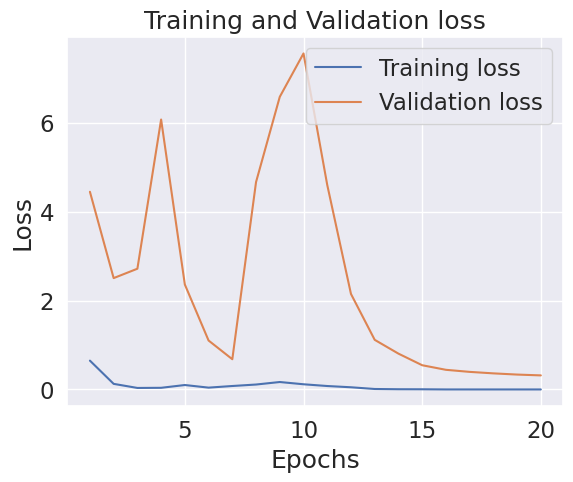

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model = keras.models.load_model('model.MobileNet.h5')

In [ ]:
results = model.evaluate(test_df, steps=len(test_df), verbose=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 612ms/step - accuracy: 1.0000 - loss: 4.0900e-05


In [ ]:
y_pred = model.predict(test_df, verbose=1).round()
y_pred = y_pred.flatten()
from sklearn.metrics import classification_report
target_names= ['not fractured', 'fractured']
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 479ms/step
               precision    recall  f1-score   support

not fractured     1.0000    1.0000    1.0000       199
    fractured     1.0000    1.0000    1.0000       200

     accuracy                         1.0000       399
    macro avg     1.0000    1.0000    1.0000       399
 weighted avg     1.0000    1.0000    1.0000       399



               precision    recall  f1-score   support

not fractured     1.0000    1.0000    1.0000       199
    fractured     1.0000    1.0000    1.0000       200

     accuracy                         1.0000       399
    macro avg     1.0000    1.0000    1.0000       399
 weighted avg     1.0000    1.0000    1.0000       399



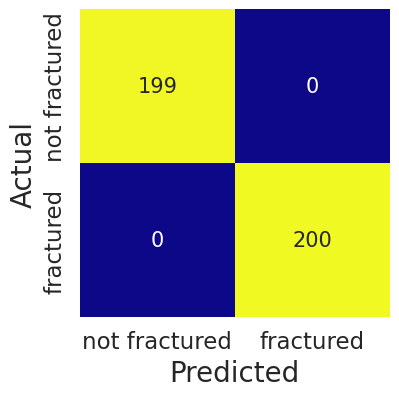

In [ ]:
from sklearn.metrics import confusion_matrix
from imblearn.metrics import sensitivity_specificity_support
from sklearn.metrics import classification_report
import seaborn as sn
import pandas as pd

report=classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)


disp = confusion_matrix(y_true, y_pred)
disp.astype('int')
pd.options.display.float_format = '{:.5f}'.format
df_cm = pd.DataFrame(disp, target_names, target_names)
# plt.figure(figsize=(10,7))
fig, ax = plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5) # for label size
sn.heatmap(df_cm, annot=True, annot_kws={"size": 15},ax=ax, cmap="plasma" , fmt='g',cbar=False) # font size
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat", bbox_inches='tight')
plt.show()


## Xception

In [ ]:
OPTIMIZER =Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
base_model=tf.keras.applications.xception.Xception(include_top=False, weights="imagenet",input_shape=IMG_SHAPE)

base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid',name='Final')(x)
model = Model(inputs=base_model.input, outputs=predictions)
#model.load_weights(dire)
model.compile(loss ='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy'])
#model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
callbacks = get_callbacks('Xception')
history = model.fit( train_df,epochs=20,
                    validation_data= val_df,
                    callbacks=[callbacks])

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7696 - loss: 0.5082   
Epoch 1: val_loss improved from None to 1.45537, saving model to model.Xception.h5



Epoch 1: finished saving model to model.Xception.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.8145 - loss: 0.4204 - val_accuracy: 0.4752 - val_loss: 1.4554 - learning_rate: 0.0010
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9218 - loss: 0.2335
Epoch 2: val_loss did not improve from 1.45537
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 643ms/step - accuracy: 0.9173 - loss: 0.2032 - val_accuracy: 0.4926 - val_loss: 5.0722 - learning_rate: 0.0010
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9223 - loss: 0.1862
Epoch 3: val_loss did not improve from 1.45537
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 668ms/step - accuracy: 0.9148 - loss: 0.1976 - val_accuracy: 0.4950 - val_loss: 10.5182 - learning_rate: 0.0010
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9832 - loss: 0.0823
Epoch 4: val_loss did not improve from 1.45537
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 650ms/step - accuracy: 0.9825 - loss: 0.0644 - val_accuracy: 0.7525 - val_loss: 3.8599 - learni


Epoch 7: finished saving model to model.Xception.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9900 - loss: 0.0375 - val_accuracy: 0.8465 - val_loss: 1.1301 - learning_rate: 5.0000e-04
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.9968 - loss: 0.0172
Epoch 8: val_loss did not improve from 1.13005
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9975 - loss: 0.0216 - val_accuracy: 0.8069 - val_loss: 1.1772 - learning_rate: 5.0000e-04
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 1.0000 - loss: 0.0085
Epoch 9: val_loss improved from 1.13005 to 0.90619, saving model to model.Xception.h5



Epoch 9: finished saving model to model.Xception.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.8663 - val_loss: 0.9062 - learning_rate: 5.0000e-04
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 10: val_loss improved from 0.90619 to 0.59321, saving model to model.Xception.h5



Epoch 10: finished saving model to model.Xception.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8960 - val_loss: 0.5932 - learning_rate: 5.0000e-04
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 11: val_loss improved from 0.59321 to 0.36733, saving model to model.Xception.h5



Epoch 11: finished saving model to model.Xception.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9233 - val_loss: 0.3673 - learning_rate: 5.0000e-04
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 1.0000 - loss: 3.7802e-04
Epoch 12: val_loss improved from 0.36733 to 0.22487, saving model to model.Xception.h5



Epoch 12: finished saving model to model.Xception.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 1.0000 - loss: 4.7238e-04 - val_accuracy: 0.9505 - val_loss: 0.2249 - learning_rate: 5.0000e-04
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 1.0000 - loss: 4.9663e-04
Epoch 13: val_loss improved from 0.22487 to 0.17766, saving model to model.Xception.h5



Epoch 13: finished saving model to model.Xception.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 1.0000 - loss: 7.3876e-04 - val_accuracy: 0.9604 - val_loss: 0.1777 - learning_rate: 5.0000e-04
Epoch 14/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 14: val_loss did not improve from 0.17766
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 683ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9703 - val_loss: 0.1784 - learning_rate: 5.0000e-04
Epoch 15/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 1.0000 - loss: 8.9976e-04
Epoch 15: val_loss did not improve from 0.17766
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 1.0000 - loss: 7.9947e-04 - val_accuracy: 0.9703 - val_loss: 0.1903 - learning_rate: 5.0000e-04
Epoch 16/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 1.0000 - loss: 3.0190e-04
Epoch 16: val_loss did not improve from 0.17766
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 627ms/step - accuracy: 1.0000 - loss: 2.3253e-04 - val_accuracy:

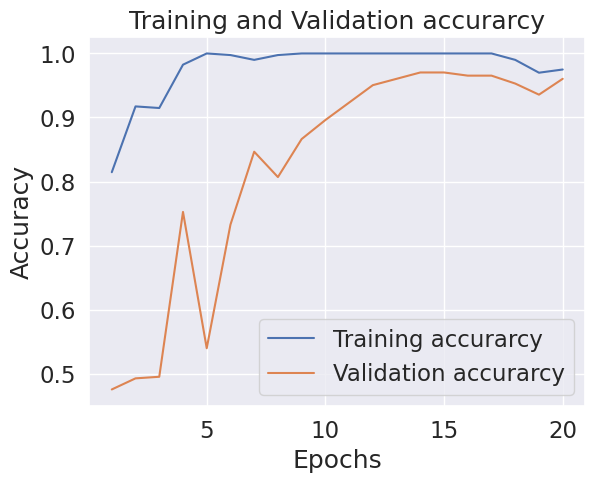

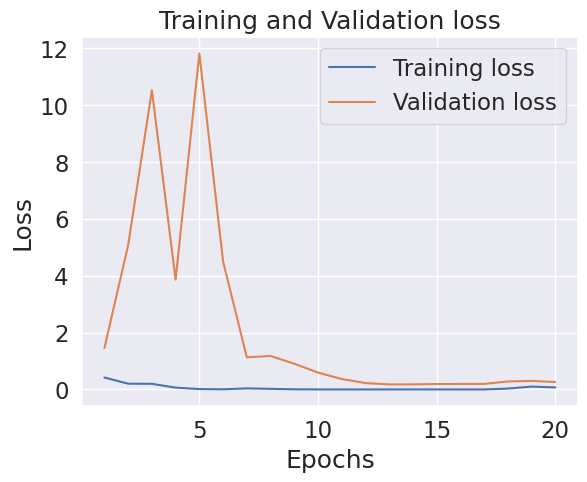

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model = keras.models.load_model('model.Xception.h5')

In [ ]:
results = model.evaluate(test_df, steps=len(test_df), verbose=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 407ms/step - accuracy: 1.0000 - loss: 6.5500e-04


In [ ]:
y_pred = model.predict(test_df, verbose=1).round()
y_pred = y_pred.flatten()
from sklearn.metrics import classification_report
target_names= ['not fractured', 'fractured']
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 492ms/step
               precision    recall  f1-score   support

not fractured     1.0000    1.0000    1.0000       199
    fractured     1.0000    1.0000    1.0000       200

     accuracy                         1.0000       399
    macro avg     1.0000    1.0000    1.0000       399
 weighted avg     1.0000    1.0000    1.0000       399



               precision    recall  f1-score   support

not fractured     1.0000    1.0000    1.0000       199
    fractured     1.0000    1.0000    1.0000       200

     accuracy                         1.0000       399
    macro avg     1.0000    1.0000    1.0000       399
 weighted avg     1.0000    1.0000    1.0000       399



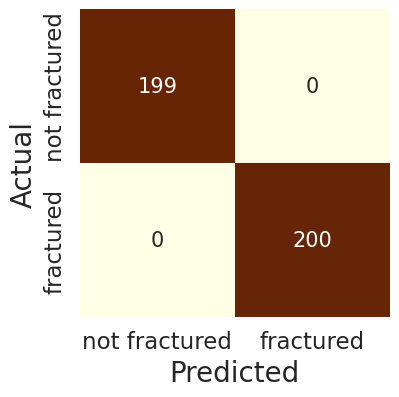

In [ ]:
from sklearn.metrics import confusion_matrix
from imblearn.metrics import sensitivity_specificity_support
from sklearn.metrics import classification_report
import seaborn as sn
import pandas as pd

target_names= ['not fractured', 'fractured']


report=classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)


disp = confusion_matrix(y_true, y_pred)
disp.astype('int')
pd.options.display.float_format = '{:.5f}'.format
df_cm = pd.DataFrame(disp, target_names, target_names)
# plt.figure(figsize=(10,7))
fig, ax = plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5) # for label size
sn.heatmap(df_cm, annot=True, annot_kws={"size": 15},ax=ax, cmap="YlOrBr" , fmt='g',cbar=False) # font size
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat", bbox_inches='tight')
plt.show()
